# Follow-along — Recitation 2: from vectors to PCA

**CPSY 1291 · Computational Cognitive Science · Brown University**

This notebook is the companion to **Recitation 2**. It is **optional and
ungraded**, like the recitation itself. The parts marked
**RUN WITH ME (in recitation)** are the ones we do together; the parts marked
**AT HOME** — including the skeleton corner and the PCA-mechanics section —
are for afterward, and 80 minutes cannot fit them. If you missed the session,
the notebook stands on its own; work top to bottom. It assumes the
Recitation 1 follow-along or equivalent numpy.

**How the exercises work** (same rules as before): each exercise cell comes
pre-filled with one possible answer so the notebook runs cleanly end to end.
Delete the sample answer, write your own, and run the locked check cell below
it. You cannot break anything.

## 1. A bench-top copy of Assignment 1 — RUN WITH ME (in recitation)

One dataset threads through this whole notebook, and it is a miniature of
A1's world. **Five toy objects** — a cube, a ball, a star, a cone, and a
torus — were each photographed from **3 views** and pushed through a tiny
**6-unit network**, giving `F`: a `(15, 6)` **stimuli × features** matrix.
Later we will simulate similarity *ratings* for every pair of the 15 images.

The point of a toy world is that **we planted the ground truth ourselves**.
When a pipeline recovers numbers we know we put in, we trust it enough to
point at real data — that is the habit this notebook drills.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import curve_fit
from scipy.stats import spearmanr
from sklearn.decomposition import PCA

rng = np.random.default_rng(1291)     # seeded: everyone sees the same numbers

n_obj, n_views, p = 5, 3, 6
obj = np.repeat(np.arange(n_obj), n_views)        # (15,) which object each row shows
obj_names = ["cube", "ball", "star", "cone", "torus"]

proto = rng.normal(0.0, 1.2, size=(n_obj, p))     # each object's prototype response
F = proto[obj] + rng.normal(0.0, 0.35, size=(n_obj * n_views, p))   # view jitter

print("F.shape:", F.shape, "  <- 5 objects x 3 views, 6 units")
print("obj:    ", obj)

F.shape: (15, 6)   <- 5 objects x 3 views, 6 units
obj:     [0 0 0 1 1 1 2 2 2 3 3 3 4 4 4]


## 2. Condensed vs square — RUN WITH ME (in recitation)

An $n \times n$ distance matrix stores $n(n-1)/2$ facts twice (plus a zero
diagonal), so SciPy has both forms — and half the "my distance matrix is the
wrong shape" errors this month are these two being confused. `imshow` and
`MDS(dissimilarity='precomputed')` want **square**; `linkage` (2h's
tree-builder) wants **condensed**.

condensed: (105,)    square: (15, 15)    back: (105,)


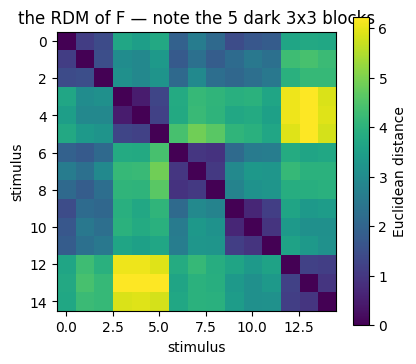

In [2]:
d = pdist(F)                          # CONDENSED: every pair once, fixed order
D = squareform(d)                     # SQUARE:    (15, 15)
d_back = squareform(D, checks=False)  # and back again

print("condensed:", d.shape, "   square:", D.shape, "   back:", d_back.shape)

plt.figure(figsize=(4.5, 4))
plt.imshow(D)
plt.colorbar(label="Euclidean distance")
plt.xlabel("stimulus")
plt.ylabel("stimulus")
plt.title("the RDM of F — note the 5 dark 3x3 blocks")
plt.show()

The five dark blocks on the diagonal are the five objects: three views of the
same object sit close together. The picture is the sanity check the numbers
cannot give — always look at an RDM before computing on it.

### Exercise 2.1 — how big is condensed? — RUN WITH ME (in recitation)

Every pair once, no diagonal, is $n(n-1)/2$. Compute `n_pairs_15` for our 15
stimuli and `n_pairs_120` for A1's 120 — the number you will see over and
over as the length of `D[iu]` and of `pdist`'s output. (Use integer division
`//` so the results are ints.)

In [3]:
n_pairs_15 = 15 * 14 // 2     # one possible answer — delete and write your own
n_pairs_120 = 120 * 119 // 2  # one possible answer — delete and write your own

In [4]:
# Check cell — run me, do not edit me.
assert n_pairs_15 == 105, (
    f"n_pairs_15 should be 105, not {n_pairs_15} — n*(n-1)/2 with n = 15. "
    "If you got 210, you counted every pair twice (n*(n-1)); if 225, you counted "
    "the diagonal too (n*n).")
assert n_pairs_120 == 7140, (
    f"n_pairs_120 should be 7140, not {n_pairs_120} — same formula, n = 120.")
assert d.shape == (n_pairs_15,), "pdist(F) should have exactly n_pairs_15 entries."
print("Exercise 2.1 passed. 7,140 is no magic number — it is every pair of 120")
print("stimuli exactly once, and A1 leans on that count repeatedly.")

Exercise 2.1 passed. 7,140 is no magic number — it is every pair of 120
stimuli exactly once, and A1 leans on that count repeatedly.


## 3. Comparing two RDMs — RUN WITH ME (in recitation)

Suppose the recording had only caught the **first three units** — an "early,
partial view" of the same stimuli. How similar is that geometry to the full
one? The course's standard move: take each RDM's **upper triangle in fixed
pair order**, and Spearman-correlate the two vectors. Spearman = Pearson on
**ranks** — only the *ordering* of dissimilarities is trusted.

In [5]:
D_early = squareform(pdist(F[:, :3]))       # RDM from units 0-2 only
iu = np.triu_indices(15, k=1)               # each pair once, no diagonal

rho = spearmanr(D[iu], D_early[iu]).statistic     # .statistic is where the number lives
print("rho (upper triangles):  ", round(rho, 3))

# The tempting shortcut — whole matrices — inflates the answer for no reason:
print("rho (whole matrices):   ", round(spearmanr(D.ravel(), D_early.ravel()).statistic, 3))

rho (upper triangles):   0.934
rho (whole matrices):    0.946


The whole-matrix version counts every pair twice and throws in 15 diagonal
zeros that the two matrices trivially share — free agreement that inflates
the correlation. Here the inflation is small; with A1's 120 shared zeros it
is worse, and either way it is wrong for no benefit. `iu` on both, always.

`spearmanr` returns a result *object*: `.statistic` is the correlation,
`.pvalue` a p-value that A1's 2k will tell you not to lean on (the 7,140
pairs are not independent samples).

### Exercise 3.1 — which half carries the geometry? — RUN WITH ME (in recitation)

Build `D_late`, the RDM from the **last three units** (`F[:, 3:]`), and
compute `rho_late`, its Spearman correlation with the full `D` — upper
triangles, of course. Compare it with `rho` above: which three units carry
more of the full geometry?

In [6]:
D_late = squareform(pdist(F[:, 3:]))                 # one possible answer — delete and write your own
rho_late = spearmanr(D[iu], D_late[iu]).statistic    # one possible answer — delete and write your own

In [7]:
# Check cell — run me, do not edit me.
assert getattr(D_late, "shape", None) == (15, 15), (
    "D_late should be the (15, 15) square RDM built from F[:, 3:] — "
    "pdist gives condensed, squareform makes it square.")
assert not isinstance(rho_late, tuple) and np.ndim(rho_late) == 0, (
    "rho_late should be a single number — spearmanr returns an object; "
    "the correlation lives in .statistic.")
assert abs(rho_late - 0.709) < 0.005, (
    "rho_late is off. Two usual causes: the full matrices went in instead of the "
    "upper triangles (use [iu] on BOTH), or D_late was built from the wrong columns.")
print("Exercise 3.1 passed. rho_late =", round(float(rho_late), 3),
      "vs", 0.934, "for the first three units —")
print("the two halves of this little network do not carry the geometry equally.")
print("A1's 2k builds its whole layers-vs-behavior table from exactly this one line.")

Exercise 3.1 passed. rho_late = 0.709 vs 0.934 for the first three units —
the two halves of this little network do not carry the geometry equally.
A1's 2k builds its whole layers-vs-behavior table from exactly this one line.


## 4. The fitting pipeline, end to end — RUN WITH ME (in recitation)

Now the ratings. We simulate a participant who obeys a **planted law**: their
similarity rating for a pair falls off exponentially with distance,
$s = 10\,e^{-0.8\,d}$, plus noise, clipped to the 0–10 rating scale.
Because *we chose* $a = 10$ and $b = 0.8$, we can tell whether the pipeline
recovers them — the whole point of fitting toy data before real data.

In [8]:
s = 10.0 * np.exp(-0.8 * d) + rng.normal(0.0, 0.4, size=d.shape)
s = np.clip(s, 0.0, 10.0)          # ratings live on a 0-10 scale

print("one rating per pair:", s.shape)
print("d ranges", d.min().round(2), "to", d.max().round(2),
      " | s ranges", s.min().round(2), "to", s.max().round(2))

one rating per pair: (105,)
d ranges 0.48 to 6.22  | s ranges 0.0 to 7.48


Three helpers, defined the way A1's notebook defines them — the model
functions and the $R^2$ scorer (which section 5 opens up by hand):

In [9]:
def f_exp(d, a, b):
    return a * np.exp(-b * d)

def f_gauss(d, a, b):
    return a * np.exp(-b * d ** 2)

def r2(y, yhat):
    return 1 - ((y - yhat) ** 2).sum() / ((y - y.mean()) ** 2).sum()

The pipeline is four moves: **fit both models → evaluate both → score both
with the same $R^2$ → look at the plot.** Three things about `curve_fit` that
students otherwise learn the hard way: it returns a *tuple* (parameters
first — hence the `popt, _` unpacking); the fitted parameters go back into
your own function with a `*`, nothing is applied automatically; and the
defaults assume an easy problem — `p0` (start near the right scale: ratings
run 0–10, so $a \approx 10$) and `maxfev` (raise it, or hard fits die early)
are how you tell it otherwise.

planted:   a = 10.00  b = 0.80
recovered: a = 10.54  b = 0.82
R2 line: 0.67    R2 exponential: 0.95


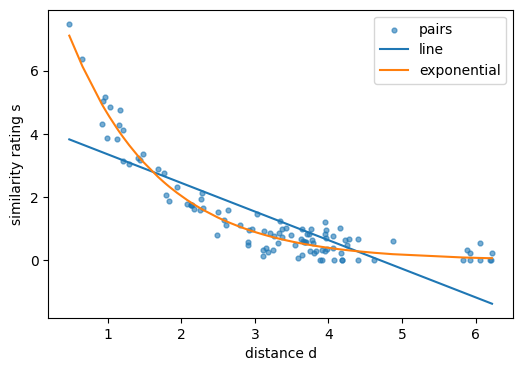

In [10]:
# the straight line: its own fit/evaluate pair
coef = np.polyfit(d, s, 1)                  # fit: slope and intercept
y_lin = np.polyval(coef, d)                 # evaluate: the line at every d

# the exponential
popt, _ = curve_fit(f_exp, d, s, p0=[10, 1], maxfev=40000)
y_exp = f_exp(d, *popt)                     # * unpacks the fitted parameters back in

print("planted:   a = 10.00  b = 0.80")
print("recovered: a =", popt[0].round(2), " b =", popt[1].round(2))
print("R2 line:", round(r2(s, y_lin), 2), "   R2 exponential:", round(r2(s, y_exp), 2))

ds = np.sort(d)
plt.figure(figsize=(6, 4))
plt.scatter(d, s, s=12, alpha=0.6, label="pairs")
plt.plot(ds, np.polyval(coef, ds), label="line")
plt.plot(ds, f_exp(ds, *popt), label="exponential")
plt.xlabel("distance d")
plt.ylabel("similarity rating s")
plt.legend()
plt.show()

Three beats to take away. The recovered parameters land near the planted
(10, 0.8) — the pipeline works, and now you know it does. Both models are
scored by the **same** `r2` against the **same** `s` — never compare fits
scored against different targets. And the plot gives a check the numbers
cannot: the line goes **negative** at large distances, where a similarity
rating never can. This four-move shape is A1's 2g exactly — swap the toy
arrays for `(d_ij, s_ij)` and you are done.

### Exercise 4.1 — the rival law — RUN WITH ME (in recitation)

Shepard's exponential has a rival: the Gaussian, `f_gauss` above, which is
flat near $d = 0$ where the exponential is already plunging. Fit it with the
same `curve_fit` call (same `p0=[10, 1]`, same `maxfev`), evaluate it, and
score it into `r2_gauss` — same scorer, same target.

In [11]:
popt_g, _ = curve_fit(f_gauss, d, s, p0=[10, 1], maxfev=40000)  # one possible answer — delete and write your own
r2_gauss = r2(s, f_gauss(d, *popt_g))                           # one possible answer — delete and write your own

In [12]:
# Check cell — run me, do not edit me.
assert np.ndim(r2_gauss) == 0, (
    "r2_gauss should be one number: r2(s, f_gauss(d, *popt_g)).")
assert abs(r2_gauss - 0.9) < 0.02, (
    "r2_gauss is off. Check that the fitted parameters went back into f_gauss "
    "with a * (f_gauss(d, *popt_g)), and that the target is s — the same target "
    "the other two models were scored against.")
assert r2_gauss < 0.95, (
    "The Gaussian should score below the exponential here — if not, a fit got "
    "scored against the wrong target.")
print("Exercise 4.1 passed. R2:", 0.67, "(line) <", round(float(r2_gauss), 2),
      "(Gaussian) <", 0.95, "(exponential).")
print("The exponential wins here because the exponential is the truth here —")
print("we planted it. 2g asks the same question of data where nobody planted anything.")

Exercise 4.1 passed. R2: 0.67 (line) < 0.9 (Gaussian) < 0.95 (exponential).
The exponential wins here because the exponential is the truth here —
we planted it. 2g asks the same question of data where nobody planted anything.


## 5. R² by hand — RUN WITH ME (in recitation)

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

The top sum is what your model gets wrong; the bottom is what a model that
predicts the mean everywhere gets wrong. $R^2$ is the fraction of that
baseline error your curve removes: 1 = perfect, 0 = no better than a flat
line through the mean, and yes — it can go **negative** (worse than knowing
nothing but the average). A1's 2g setup cell defines `r2` with this exact
formula; you are not asked to write it, you are asked to *read* it — so once,
by hand:

### Exercise 5.1 — compute it yourself — RUN WITH ME (in recitation)

A fit predicts $\hat{y} = (3, 4, 5, 8, 10)$ where the data say
$y = (2, 4, 6, 8, 10)$. Compute `r2_hand` from the formula — numpy or mental
arithmetic, your choice. (Residuals first, then the deviations from the mean.)

In [13]:
y = np.array([2.0, 4.0, 6.0, 8.0, 10.0])
yhat = np.array([3.0, 4.0, 5.0, 8.0, 10.0])

r2_hand = 1 - ((y - yhat) ** 2).sum() / ((y - y.mean()) ** 2).sum()  # one possible answer — delete and write your own

In [14]:
# Check cell — run me, do not edit me.
assert abs(r2_hand - 0.95) < 1e-9, (
    "Expected 0.95. The residuals are (-1, 0, -1, 0, 0), so the top sum is 2; "
    "the mean of y is 6, deviations (-4, -2, 0, 2, 4), bottom sum 40; "
    "1 - 2/40 = 0.95. If you got 0.05, the 1 - went missing; if something "
    "negative and large, top and bottom are swapped.")
print("Exercise 5.1 passed. And two follow-ups worth a moment's thought:")
print("a model that predicts the mean everywhere scores exactly 0 (the two sums")
print("coincide), and a model WORSE than that scores negative.")

Exercise 5.1 passed. And two follow-ups worth a moment's thought:
a model that predicts the mean everywhere scores exactly 0 (the two sums
coincide), and a model WORSE than that scores negative.


One caveat to carry into 2g: $R^2$ is a **ratio**, so it depends on how
variable $y$ was to begin with. Average your data into bins first and $R^2$
rises — with the fitted curve completely unchanged, because binning shrank
the denominator. Two $R^2$ values are comparable **only against the same
target**; that is 2g's question about published gradients, almost verbatim.

## 6. The scikit-learn pattern, and what PCA gives you — RUN WITH ME (in recitation)

**PCA** takes your (items × features) matrix and returns **new axes for the
same points** — directions in feature space, **ordered** by how much of the
data's spread each captures. PC1 is the single direction of greatest spread;
each next component is perpendicular to the ones before and explains less.
PCA does not change your data — it re-describes the same points along better
axes.

Every scikit-learn estimator has the same shape of call: settings go in the
constructor, data goes to `.fit` (or `fit_transform`), and everything the
estimator *learned* grows a **trailing underscore** — which is not a typo, it
marks attributes that exist only after fitting.

In [15]:
est = PCA()                       # settings in the constructor (defaults here)
Y = est.fit_transform(F)          # data to fit_transform

print("Y.shape:", Y.shape, " <- same 15 stimuli, new ordered axes")
print("explained_variance_ratio_:", est.explained_variance_ratio_.round(3))

# the trailing underscore is not decoration — before .fit, it does not exist:
try:
    PCA().explained_variance_ratio_
except AttributeError as e:
    print("before fitting ->", type(e).__name__, "-", e)

Y.shape: (15, 6)  <- same 15 stimuli, new ordered axes
explained_variance_ratio_: [0.643 0.195 0.091 0.049 0.019 0.004]
before fitting -> AttributeError - 'PCA' object has no attribute 'explained_variance_ratio_'


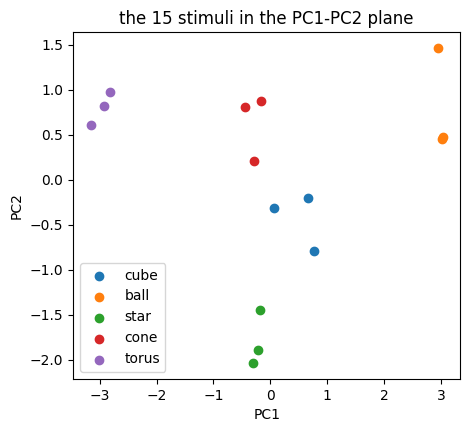

In [16]:
plt.figure(figsize=(5, 4.5))
for k in range(n_obj):
    pts = Y[obj == k]
    plt.scatter(pts[:, 0], pts[:, 1], label=obj_names[k])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("the 15 stimuli in the PC1-PC2 plane")
plt.legend()
plt.show()

Five clumps of three — the first two axes already know there are five
objects. A1's part 3 draws exactly this plot for 1,224 images.

**Variance explained**, and the one-line answer to "how many components reach
85%": `cumsum` is a running total, and `argmax` of a boolean array returns
the **first True** (because `True > False`). Careful with the off-by-one:
`argmax` returns an *index*, and indices start at 0, so the *count* of
components is index + 1.

In [17]:
cum = np.cumsum(est.explained_variance_ratio_)
print("cumulative:", cum.round(3))

first = np.argmax(cum >= 0.85)      # index of the first component that crosses 85%
print("first index where cum >= 0.85:", first, " -> that is", first + 1, "components")

cumulative: [0.643 0.837 0.928 0.977 0.996 1.   ]
first index where cum >= 0.85: 2  -> that is 3 components


### Exercise 6.1 — components to reach 95% — RUN WITH ME (in recitation)

Same move, higher bar: compute `k95`, the **number of components** (a count,
not an index) needed for the cumulative explained variance to reach 0.95.

In [18]:
k95 = np.argmax(cum >= 0.95) + 1  # one possible answer — delete and write your own

In [19]:
# Check cell — run me, do not edit me.
assert k95 == 4, (
    f"k95 should be 4, not {k95}. If you are off by one, remember argmax "
    "returns the INDEX of the first True and indices start at 0 — the count is "
    "index + 1. If you are far off, check the comparison: cum >= 0.95.")
print("Exercise 6.1 passed. In A1's 3b this same line runs on real activations —")
print("and 3c will make you ask what that count is actually a fact about.")

Exercise 6.1 passed. In A1's 3b this same line runs on real activations —
and 3c will make you ask what that count is actually a fact about.


## 7. Groupby without groupby — THE template — RUN WITH ME (in recitation)

"Per-group anything" in pure numpy is one line with four moves:

In [20]:
means = np.stack([F[obj == k].mean(axis=0) for k in range(n_obj)])
print("means.shape:", means.shape, " <- one mean feature vector per object")

means.shape: (5, 6)  <- one mean feature vector per object


1. `obj == k` — boolean mask: which rows belong to object $k$
2. `F[obj == k]` — those rows: `(3, 6)`
3. `.mean(axis=0)` — collapse the 3 views: `(6,)`
4. `np.stack([...])` — pile the 5 results into one `(5, 6)` array

Steps 1–2 are Recitation 1's masks; step 3 is the axis rule; `np.stack` is
the only new word. When an assignment says "for each object / category /
cluster, compute ...", this is the shape of the answer — with a different
word in step 3. A1's 3c needs exactly this line, at `(1224, 4096)` scale.

### Exercise 7.1 — the template with a different word — RUN WITH ME (in recitation)

Compute `pc1_mean`: for each of the 5 objects, the mean of its 3 views'
**PC1 scores** (`Y[:, 0]` from section 6). Shape `(5,)` — the template, with
`Y[:, 0]` in place of `F` and no `axis` needed (the scores are 1-D).

In [21]:
pc1_mean = np.array([Y[obj == k, 0].mean() for k in range(n_obj)])  # one possible answer — delete and write your own

In [22]:
# Check cell — run me, do not edit me.
assert getattr(pc1_mean, "shape", None) == (5,), (
    f"pc1_mean should have shape (5,), one number per object; yours is "
    f"{getattr(pc1_mean, 'shape', None)}. Mask Y[:, 0] with obj == k inside the "
    "template.")
# Compared via abs(): a principal component's SIGN is arbitrary (see section 9),
# so your PC1 scores could legitimately be the negation of another machine's.
assert np.allclose(np.abs(pc1_mean), np.abs(np.array([0.497, 2.998, -0.232, -0.296, -2.966])), atol=0.01), (
    "pc1_mean has the wrong values — check that column 0 of Y (the PC1 scores) "
    "went into the template, not a column of F.")
print("Exercise 7.1 passed. Same template, different word — 3h's per-category")
print("silhouette scores and part 4's per-object island counts loop the same way.")

Exercise 7.1 passed. Same template, different word — 3h's per-category
silhouette scores and part 4's per-object island counts loop the same way.


## 8. AT HOME — the skeleton corner

The recitation hands out code skeletons for the four A1 sections the
test-solve showed stop people cold. Here each one **runs**, on the toy world,
so you can watch it work before pointing it at real data. Nothing below is a
solution to a graded question — these are the same skeletons the deck and
handout give everyone.

### 8a. 3c's variance split

How much of the spread in `F` is *identity* (objects differing from each
other) and how much is *viewpoint* (views of one object differing)? Three
lines, using `means` from section 7:

In [23]:
total = F.var(axis=0).sum()          # variance per feature, summed: one number
between = means.var(axis=0).sum()    # variance OF the 5 object means
within = total - between             # what viewpoint contributes

print("total:", total.round(3), "  between (identity):", between.round(3),
      "  within (viewpoint):", within.round(3))
print("identity share:", round(between / total, 3))

# Sanity check the subtraction really is the within-object part:
within_direct = np.mean(
    [F[obj == k].var(axis=0) for k in range(n_obj)], axis=0).sum()
print("within by subtraction == within computed directly:",
      np.allclose(within, within_direct))

total: 5.697   between (identity): 5.295   within (viewpoint): 0.402
identity share: 0.929
within by subtraction == within computed directly: True


In words: `total` is how spread out all 15 points are; `between` is how
spread out the 5 object *centers* are; `within` is the spread of views around
their own center, obtained by subtraction — and the direct computation
confirms the subtraction is honest. Identity dominates here because we built
the world that way. What the split means for A1's 1,224 images is 3c's
question, and it is yours.

### 8b. 3f's perimeter, handed out entire

Spikiness = perimeter² / area, from a binary silhouette mask alone. The trick:
shift the mask against itself and count where the two copies **disagree** —
every disagreement is a piece of boundary.

square  area: 121   perimeter: 44   spikiness: 16.0
plus    area: 117   perimeter: 72   spikiness: 44.31


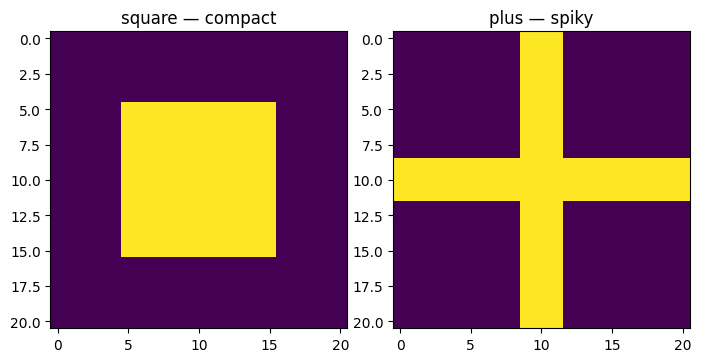

In [24]:
def perimeter(m):
    return ((m[1:, :] != m[:-1, :]).sum()     # edges between vertical neighbors
          + (m[:, 1:] != m[:, :-1]).sum())    # edges between horizontal neighbors

# Two toy silhouettes on a 21x21 grid:
yy, xx = np.mgrid[0:21, 0:21]
square = (np.abs(yy - 10) <= 5) & (np.abs(xx - 10) <= 5)   # a compact blob
plus = (np.abs(yy - 10) <= 1) | (np.abs(xx - 10) <= 1)     # thin crossed arms

for name, m in (("square", square), ("plus", plus)):
    print(name.ljust(6), " area:", m.sum(), "  perimeter:", perimeter(m),
          "  spikiness:", round(perimeter(m) ** 2 / m.sum(), 2))

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(square); axes[0].set_title("square — compact")
axes[1].imshow(plus); axes[1].set_title("plus — spiky")
plt.tight_layout()
plt.show()

The compact square scores low, the thin-armed plus scores high — boundary is
expensive relative to area when a shape is spiky. In 3f this measure gets
computed for 1,224 real silhouettes, and the required sanity gallery (blobs
at one end, spiky things at the other) is exactly the check we just did by
hand.

### Exercise 8.1 — a third silhouette — AT HOME

The mask `bar` below is a thin 3×21 horizontal bar. Before running anything,
predict: does its spikiness land below the square, between the two, or above
the plus? Then compute `spik_bar` and find out.

In [25]:
bar = (np.abs(yy - 10) <= 1)     # given: a thin horizontal bar, full width

spik_bar = perimeter(bar) ** 2 / bar.sum()  # one possible answer — delete and write your own

In [26]:
# Check cell — run me, do not edit me.
assert abs(spik_bar - 28.0) < 0.01, (
    "spik_bar is off — the formula is perimeter(bar)**2 / bar.sum(): "
    "perimeter squared, then divided by area.")
assert 16.0 < spik_bar < 44.31, (
    "spik_bar should land BETWEEN the square and the plus.")
print("Exercise 8.1 passed. spikiness:", 16.0, "(square) <",
      round(float(spik_bar), 2), "(bar) <", 44.31, "(plus) —")
print("one thin arm is spikier than a blob, two crossed arms are spikier still.")

Exercise 8.1 passed. spikiness: 16.0 (square) < 28.0 (bar) < 44.31 (plus) —
one thin arm is spikier than a blob, two crossed arms are spikier still.


### 8c. 3i's NaNs — pick one, and say which

Real electrodes drop samples; PCA accepts none of it. We plant a few NaNs in
a copy of `F` to stand in for 3i's IT recordings, then show the two
defensible one-liners: **drop** the affected units, or **impute** each unit's
mean into its holes.

In [27]:
rng_nan = np.random.default_rng(7)
it_raw = F.copy()
it_raw[rng_nan.integers(0, 15, 4), 1] = np.nan    # unit 1 dropped some samples
it_raw[rng_nan.integers(0, 15, 3), 4] = np.nan    # so did unit 4

print("NaNs planted:", np.isnan(it_raw).sum(), "  affected units:",
      np.where(np.isnan(it_raw).any(axis=0))[0])

dropped = it_raw[:, ~np.isnan(it_raw).any(axis=0)]                        # DROP affected units
imputed = np.where(np.isnan(it_raw), np.nanmean(it_raw, axis=0), it_raw)  # IMPUTE unit means

print("drop   ->", dropped.shape, "  impute ->", imputed.shape)

NaNs planted: 7   affected units: [1 4]
drop   -> (15, 4)   impute -> (15, 6)


Read them aloud. Drop: "keep the columns where no entry is NaN" —
Recitation 1's boolean machinery, `~` and `.any(axis=0)`. Impute:
three-argument `np.where(condition, if_true, if_false)` — "where it is NaN,
take that unit's `nanmean`, else keep the value."

And the ordering rule that survives both choices: **check for zero-variance
units before z-scoring.** Dividing by a std of 0 makes NaNs, and one NaN
poisons everything downstream.

### Exercise 8.2 — your call — AT HOME

Make the choice 3i will ask you to make: set `choice` to `"drop"` or
`"impute"`, and build `IT`, a matrix with **no NaNs**, from `it_raw` using
the matching one-liner. Either is defensible — the graded habit is *saying
which you chose and why*, so put a reason in the comment too.

In [28]:
choice = "drop"    # one possible answer — delete and write your own (and your reason)
IT = it_raw[:, ~np.isnan(it_raw).any(axis=0)]  # one possible answer — delete and write your own

In [29]:
# Check cell — run me, do not edit me.
assert choice in ("drop", "impute"), (
    "choice must be the string 'drop' or 'impute' — the point is stating the "
    "analytical decision out loud.")
assert not np.isnan(IT).any(), (
    "IT still contains NaNs — neither one-liner ran correctly. Check the axis: "
    "any(axis=0) asks 'does this UNIT have any NaN'.")
if choice == "drop":
    assert IT.shape == (15, 4), (
        f"With choice='drop', two affected units go away: IT should be (15, 4), "
        f"not {IT.shape}.")
else:
    assert IT.shape == (15, 6), (
        f"With choice='impute', every unit is kept: IT should be (15, 6), "
        f"not {IT.shape}.")
print("Exercise 8.2 passed, choosing to", choice + ".",
      "The other choice passes too — what")
print("is graded in 3i is that you can defend the one you made.")

Exercise 8.2 passed, choosing to drop. The other choice passes too — what
is graded in 3i is that you can defend the one you made.


### 8d. 2j's loop — the structure, not the content

2j runs your 2g fitting code six times (three layers × two networks). The
blocker is never the fitting — it is the plumbing. Here is the same loop
shape on the toy world: the real ratings against ratings **shuffled** so the
law is destroyed. The `try/except RuntimeError` matters: 2j's notebook says
the exponential may *legitimately fail to converge* on untrained layers —
that failure is a finding, not a bug in your code.

In [30]:
rng_sh = np.random.default_rng(3)

for tag, y in (("matched ", s), ("shuffled", rng_sh.permutation(s))):
    try:
        p_fit, _ = curve_fit(f_exp, d, y, p0=[10, 1], maxfev=40000)
        print(tag, " a =", p_fit[0].round(2), " b =", p_fit[1].round(2),
              " R2 =", round(r2(y, f_exp(d, *p_fit)), 3))
    except RuntimeError as e:
        print(tag, " fit did not converge —", e)

matched   a = 10.54  b = 0.82  R2 = 0.948
shuffled  a = 1.47  b = 0.03  R2 = 0.001


Shuffling breaks the pairing between distances and ratings, and the fit says
so: it collapses to a nearly flat curve ($b \approx 0$) explaining nothing
($R^2 \approx 0$). A fit can *converge* and still have found nothing — read
the parameters and the $R^2$, not just the absence of an error.

## 9. AT HOME — PCA mechanics: rows, columns, and which way to multiply

A1 mostly lets `fit_transform` do this for you, but the final project will
not — so here is what is actually inside, on data small enough to check.

sklearn stores the component directions in `est.components_`, and it stores
them **as rows**: the array is `(n_components, n_features)`, one direction
per row. The transform is then: center the data (PCA centers each feature —
each *column* — for you, the column cousin of 1b's row-centering), and take
the dot product with each direction. As one matrix multiplication, the
components must be **transposed**:

In [31]:
est2 = PCA(n_components=2)
Y2 = est2.fit_transform(F)

print("components_.shape:", est2.components_.shape,
      " <- (n_components, n_features): directions are ROWS")

Xc = F - F.mean(axis=0)                    # center each feature, as PCA does
Y_mine = Xc @ est2.components_.T           # (15,6) @ (6,2) -> (15,2)

print("Xc @ components_.T reproduces fit_transform:", np.allclose(Y_mine, Y2))

components_.shape: (2, 6)  <- (n_components, n_features): directions are ROWS
Xc @ components_.T reproduces fit_transform: True


Now trigger the mistake on purpose, so the first time you meet it is here
and not mid-project. Forget the transpose and the shapes refuse to chain —
`(15, 6) @ (2, 6)` has 6 against 2:

In [32]:
try:
    Xc @ est2.components_
except ValueError as e:
    print("ValueError:", e)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 6)


When you see this error near PCA code, check which way `components_` is
oriented before touching anything else.

**One more mechanic: signs are arbitrary.** A component is a direction —
"this way" and "exactly backwards" describe the same axis, so PC1 and
−PC1 are equally valid, and different library versions or machines can
legitimately disagree. If your PC1 scores are the negation of a
classmate's, neither of you is wrong (A1 grades accordingly — and it is why
exercise 7.1's check compared absolute values).

In [33]:
print("PC1 direction:        ", est2.components_[0].round(2))
print("equally valid PC1:    ", (-est2.components_[0]).round(2))
print("flip direction & scores together, nothing changes:",
      np.allclose(Xc @ -est2.components_[0], -Y2[:, 0]))

PC1 direction:         [-0.55  0.57 -0.27  0.53 -0.1   0.09]
equally valid PC1:     [ 0.55 -0.57  0.27 -0.53  0.1  -0.09]
flip direction & scores together, nothing changes: True


### Exercise 9.1 — reproduce fit_transform yourself — AT HOME

Fit `est3 = PCA(n_components=3)` on `F`, and build `Y3_mine` **by hand** —
center `F`, then one matrix multiplication with `est3.components_`
(remember which way it is stored). The check compares you against
`est3.transform(F)`.

In [34]:
est3 = PCA(n_components=3).fit(F)                    # one possible answer — delete and write your own
Y3_mine = (F - F.mean(axis=0)) @ est3.components_.T  # one possible answer — delete and write your own

In [35]:
# Check cell — run me, do not edit me.
assert getattr(Y3_mine, "shape", None) == (15, 3), (
    f"Y3_mine should be (15, 3) — 15 stimuli on 3 new axes; yours is "
    f"{getattr(Y3_mine, 'shape', None)}. If you hit the ValueError from above, "
    "components_ is (3, 6) and needs the .T; if you got (15, 6), F was not "
    "multiplied by the components at all.")
assert np.allclose(Y3_mine, est3.transform(F)), (
    "The shape is right but the values are off — most often the centering step "
    "was skipped: subtract F.mean(axis=0) BEFORE multiplying.")
print("Exercise 9.1 passed. That one line — center, then project — is all")
print("fit_transform does, and now you can write it anywhere sklearn is not.")

Exercise 9.1 passed. That one line — center, then project — is all
fit_transform does, and now you can write it anywhere sklearn is not.


## 10. AT HOME — what a terrible `p0` does

The session has no time for failure modes; that is what at-home sections are
for. Give `curve_fit` a start at the wrong scale — `p0=[0.001, 50]`, a curve
that is essentially zero everywhere — and watch what happens. (The overflow
warning you may see is the optimizer probing wild parameter values along
the way.)

In [36]:
for mf in (800, 40000):
    try:
        p_bad, _ = curve_fit(f_exp, d, s, p0=[0.001, 50], maxfev=mf)
        print("maxfev =", mf, "-> converged to", p_bad.round(3),
              " R2 =", round(r2(s, f_exp(d, *p_bad)), 3))
    except RuntimeError as e:
        print("maxfev =", mf, "-> RuntimeError:", e)

maxfev = 800 -> RuntimeError: Optimal parameters not found: gtol=0.000000 is too small, func(x) is orthogonal to the columns of
  the Jacobian to machine precision.
maxfev = 40000 -> RuntimeError: Optimal parameters not found: gtol=0.000000 is too small, func(x) is orthogonal to the columns of
  the Jacobian to machine precision.


/var/folders/28/5s7zvl2554v3h672hq2bg9500000gr/T/ipykernel_69303/518018403.py:2: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * d)


Note what did *not* fix it: raising `maxfev` from 800 to 40,000 changed
nothing, because the problem is not patience. With $b = 50$ the model is flat
zero at every data point, so the fit error barely responds to the parameters —
the optimizer is standing on a plain with no slope to follow, and it gives up.

The two lessons, in order of importance: **start `p0` at the scale of your
data** (ratings run 0–10, so $a \approx 10$; distances run a few units, so
$b$ near 1) — that is why the pipeline in section 4 used `p0=[10, 1]`. And
when a fit is *allowed* to fail (2j says so explicitly), wrap it in
`try/except RuntimeError` and report the failure — it may be the finding.

## 11. Where this goes next

You have now run, on a world you built yourself, every pipeline that A1's
parts 2–3 lean on: condensed vs square, RDM comparison with
`spearmanr(...).statistic`, the four-move fitting pipeline, $R^2$ from its
formula, the sklearn pattern, PCA and its mechanics, the groupby template,
and the four handed-out skeletons. The
[Recitation 2 deck](https://serre-lab.github.io/CPSY1291-2026/recitations/recitation-02-vectors-to-pca.html)
covers the same ground on slides — including two calls this notebook only
points at: `linkage`/`fcluster` for 2h's tree, and `silhouette_score` for 3h
(coordinates in, not the RDM — and no relation to 3f's silhouette *masks*;
the name is a coincidence). A one-page **call sheet** with all the library
signatures is coming to the Canvas Recitations module.

A reminder, one more time: this notebook, like the recitations, is
**optional and ungraded**. Bring the parts that resisted you to office hours
— with the failing cell open, and its shapes already printed.